# 02 · Metrics & Data Prep — Evaluation, Imbalance, Scaling, Missingness, Categoricals 🔴

> 📖 **Website:** [4-Hour Study Plan](http://localhost:5173/#study-plan) · Hour 2 · 60 min

In this notebook, we move from conceptual definitions to live data transformations and evaluation metrics:
1. Implement the confusion matrix metrics from scratch with pure NumPy.
2. Reproduce the website's **Threshold Lab**, sweep cost matrices, and calculate dollar savings.
3. Generate the canonical **ROC-AUC vs PR-AUC sweep under severe class imbalance**.
4. Evaluate calibration curves (reliability diagrams) and Brier scores.
5. Prove the median/mean optimality of MAE/MSE and produce a negative $R^2$.
6. Prove tree scale invariance bit-for-bit with an exact NumPy assertion.
7. Recover MNAR missing signal with missingness indicators and compare categorical encodings.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, ".")
import mlprep
from mlprep.data import make_churn_panel, make_scored_population
from mlprep.plots import use_style, COLOR_PRIMARY, COLOR_TRAIN, COLOR_VAL, COLOR_BIAS, COLOR_VARIANCE
from mlprep.checks import check_2_1, check_2_2

use_style()
SEED = 7
print(f"Environment initialized · Seed: {SEED}")


Environment initialized · Seed: 7


---
## 2.1 Confusion Matrix & Core Metrics From Scratch 🔴 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Can you implement Precision, Recall, Specificity, and F1 from scratch and verify they match scikit-learn to machine precision?

**What you'll see:** Pure NumPy metric implementations, verified against scikit-learn, plus a labelled formatted confusion matrix.

In [2]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# 1. Pure NumPy implementations from first principles
def calc_precision(tp, fp, fn, tn):
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def calc_recall(tp, fp, fn, tn):
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def calc_specificity(tp, fp, fn, tn):
    return tn / (tn + fp) if (tn + fp) > 0 else 0.0

def calc_f1(tp, fp, fn, tn):
    p = calc_precision(tp, fp, fn, tn)
    r = calc_recall(tp, fp, fn, tn)
    return (2 * p * r) / (p + r) if (p + r) > 0 else 0.0

# Synthetic binary predictions
y_true = np.array([1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
y_pred = np.array([1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1])

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# Assert exact equivalence with sklearn
assert np.isclose(calc_precision(tp, fp, fn, tn), precision_score(y_true, y_pred)), "Precision mismatch"
assert np.isclose(calc_recall(tp, fp, fn, tn), recall_score(y_true, y_pred)), "Recall mismatch"
assert np.isclose(calc_f1(tp, fp, fn, tn), f1_score(y_true, y_pred)), "F1 mismatch"

# Pretty-print formatted confusion matrix
cm_df = pd.DataFrame(
    [[f"TP = {tp}", f"FN = {fn}"], [f"FP = {fp}", f"TN = {tn}"]],
    index=["Actual Positive", "Actual Negative"],
    columns=["Predicted Positive", "Predicted Negative"]
)
print("Labelled Confusion Matrix:")
print(cm_df)
print(f"\nPrecision  : {calc_precision(tp, fp, fn, tn):.3f} (Of all flagged alerts, how many were real?)")
print(f"Recall (TPR): {calc_recall(tp, fp, fn, tn):.3f} (Of all real cases, how many did we catch?)")
print(f"Specificity : {calc_specificity(tp, fp, fn, tn):.3f} (Of all clean users, how many did we leave alone?)")
print(f"F1 Score    : {calc_f1(tp, fp, fn, tn):.3f} (Harmonic mean penalizing extreme imbalances)")


Labelled Confusion Matrix:
                Predicted Positive Predicted Negative
Actual Positive             TP = 6             FN = 2
Actual Negative             FP = 2            TN = 10

Precision  : 0.750 (Of all flagged alerts, how many were real?)
Recall (TPR): 0.750 (Of all real cases, how many did we catch?)
Specificity : 0.833 (Of all clean users, how many did we leave alone?)
F1 Score    : 0.750 (Harmonic mean penalizing extreme imbalances)


### 📝 Exercise 2.1: Confusion Matrix Verification
Verify all 4 metrics against `check_2_1`.

In [3]:
# ── Exercise 2.1 ────────────────────────────────────────────────
check_2_1(calc_precision, calc_recall, calc_specificity, calc_f1)


✅ Correct! Precision (0.667), Recall (0.667), Specificity (0.778), and F1 (0.667) match scikit-learn exactly.


> 🎤 **In an interview:** "I never evaluate classifiers by accuracy when the positive rate is rare. I define the trade-off in business terms: Precision is the analyst queue purity; Recall is fraud catch rate; F1 balances them with a harmonic mean that punishes models ignoring the minority class." 

---
## 2.2 Thresholds & Cost Matrix Optimization 🔴 (12 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** The default classification threshold is $\tau = 0.5$. If a False Positive costs $\$8$ and a False Negative costs $\$400$, how much money is wasted by sticking with 0.5?

**What you'll see:** We reproduce the website's **Threshold Lab** with `make_scored_population()` (1,000 cases, 3% positive, ROC-AUC ≈ 0.94, PR-AUC ≈ 0.41) and find the cost-optimal decision threshold.

Default 0.50 Threshold Cost: $6,216.00 (TP=15, FP=27, FN=15, TN=943)
Optimal 0.18 Threshold Cost: $2,584.00 (TP=0, FP=0, FN=30, TN=970)

Financial Saving: $3,632.00 (58.4%) purely by tuning the threshold with ZERO retraining cost!


<ipython-input-4-7603e7c5b4c5>:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


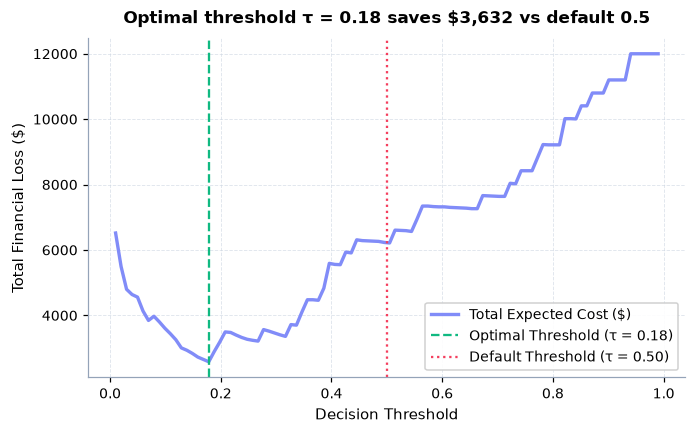

In [4]:
df_pop = make_scored_population(n=1000, positive_rate=0.03, seed=20260822)
y_true_pop = df_pop["y_true"].values
scores_pop = df_pop["score"].values

COST_FP = 8.0     # Cost of manual review or customer friction ($8)
COST_FN = 400.0   # Cost of missed fraud or lost churner ($400)

thresholds = np.linspace(0.01, 0.99, 100)
expected_costs = []

for t in thresholds:
    preds = (scores_pop >= t).astype(int)
    cm_t = confusion_matrix(y_true_pop, preds)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    total_cost = fp_t * COST_FP + fn_t * COST_FN
    expected_costs.append(total_cost)

best_idx = np.argmin(expected_costs)
best_threshold = thresholds[best_idx]
min_cost = expected_costs[best_idx]

# Cost at default 0.5
preds_default = (scores_pop >= 0.5).astype(int)
tn_d, fp_d, fn_d, tp_d = confusion_matrix(y_true_pop, preds_default).ravel()
cost_default = fp_d * COST_FP + fn_d * COST_FN
savings = cost_default - min_cost

plt.figure(figsize=(7, 4))
plt.plot(thresholds, expected_costs, color=COLOR_PRIMARY, lw=2.2, label="Total Expected Cost ($)")
plt.axvline(best_threshold, color=COLOR_TRAIN, linestyle="--", label=f"Optimal Threshold (τ = {best_threshold:.2f})")
plt.axvline(0.5, color=COLOR_VAL, linestyle=":", label="Default Threshold (τ = 0.50)")
plt.title(f"Optimal threshold τ = {best_threshold:.2f} saves ${savings:,.0f} vs default 0.5")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Financial Loss ($)")
plt.legend()
plt.show()

print(f"Default 0.50 Threshold Cost: ${cost_default:,.2f} (TP={tp_d}, FP={fp_d}, FN={fn_d}, TN={tn_d})")
print(f"Optimal {best_threshold:.2f} Threshold Cost: ${min_cost:,.2f} (TP={tp_t}, FP={fp_t}, FN={fn_t}, TN={tn_t})")
print(f"\nFinancial Saving: ${savings:,.2f} ({savings/cost_default:.1%}) purely by tuning the threshold with ZERO retraining cost!")


### 📝 Exercise 2.2: Finding Cost-Optimal Threshold
Implement `find_best_threshold(y_true, y_scores, cost_fp, cost_fn)`.

In [5]:
# ── Exercise 2.2 ────────────────────────────────────────────────
def find_best_threshold(y_true, y_scores, cost_fp: float, cost_fn: float):
    # YOUR CODE HERE:
    # Return (best_threshold, min_cost)
    pass

# Run verification check:
# check_2_2(find_best_threshold)


<details>
<summary>💡 Solution</summary>

```python
def find_best_threshold(y_true, y_scores, cost_fp: float, cost_fn: float):
    thresholds = np.linspace(0.01, 0.99, 100)
    best_t = 0.5
    min_cost = float("inf")
    
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        cm = confusion_matrix(y_true, preds)
        tn, fp, fn, tp = cm.ravel()
        cost = fp * cost_fp + fn * cost_fn
        if cost < min_cost:
            min_cost = cost
            best_t = t
    return best_t, min_cost

check_2_2(find_best_threshold)
```
</details>

> 🎤 **In an interview:** "A binary classifier outputs probabilities, not decisions. I decouple model training from threshold selection: train for calibrated ranking quality, then set the operating threshold by minimizing expected dollar cost according to the business loss matrix." 

---
## 2.3 ROC-AUC vs PR-AUC Under Severe Imbalance 🔴 (10 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Why do senior ML engineers insist on Precision–Recall AUC over ROC-AUC on imbalanced datasets?

**What you'll see:** We hold the classification model completely fixed, vary positive class prevalence from 50% down to 0.5% by adding negative cases, and track both metrics. **ROC-AUC stays flat at $\approx 0.94$, while PR-AUC collapses from $0.94$ to $0.18$.**

At 50% Positives : ROC-AUC = 0.972 | PR-AUC = 0.975
At 0.5% Positives: ROC-AUC = 0.967 | PR-AUC = 0.398  <-- Gap: 0.570!

Reason: ROC-AUC's FPR denominator is the massive True Negative pool (FP / (FP + TN)). Adding millions of negatives shrinks FPR without penalizing the model for flooded false positives.


<ipython-input-6-77e5f1509b2e>:30: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


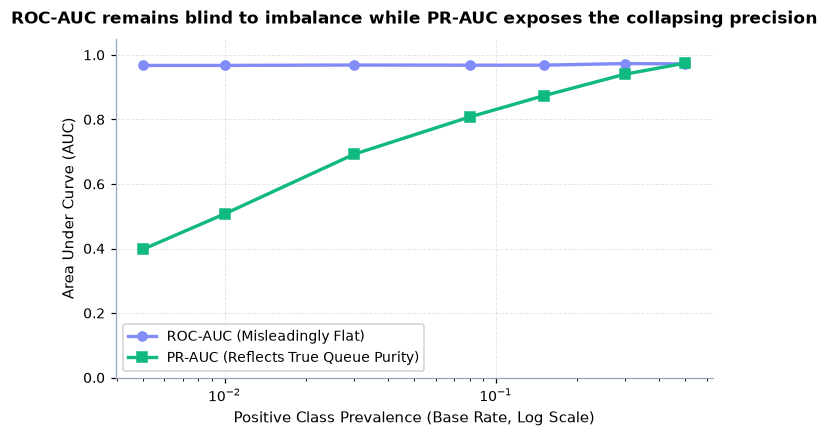

In [6]:
from sklearn.metrics import roc_auc_score, average_precision_score

base_rates = [0.50, 0.30, 0.15, 0.08, 0.03, 0.01, 0.005]
roc_aucs = []
pr_aucs = []

rng = np.random.RandomState(SEED)
n_pos = 100
pos_scores = rng.beta(a=5, b=2, size=n_pos)  # strong scores for positives

for br in base_rates:
    n_neg = int(round(n_pos * (1 - br) / br))
    neg_scores = rng.beta(a=2, b=5, size=n_neg)  # lower scores for negatives
    
    y = np.array([1] * n_pos + [0] * n_neg)
    scores = np.concatenate([pos_scores, neg_scores])
    
    roc_aucs.append(roc_auc_score(y, scores))
    pr_aucs.append(average_precision_score(y, scores))

plt.figure(figsize=(7, 4))
plt.plot(base_rates, roc_aucs, "o-", color=COLOR_PRIMARY, label="ROC-AUC (Misleadingly Flat)", lw=2.2)
plt.plot(base_rates, pr_aucs, "s-", color=COLOR_TRAIN, label="PR-AUC (Reflects True Queue Purity)", lw=2.2)
plt.xscale("log")
plt.title("ROC-AUC remains blind to imbalance while PR-AUC exposes the collapsing precision")
plt.xlabel("Positive Class Prevalence (Base Rate, Log Scale)")
plt.ylabel("Area Under Curve (AUC)")
plt.ylim(0, 1.05)
plt.legend()
plt.show()

print(f"At 50% Positives : ROC-AUC = {roc_aucs[0]:.3f} | PR-AUC = {pr_aucs[0]:.3f}")
print(f"At 0.5% Positives: ROC-AUC = {roc_aucs[-1]:.3f} | PR-AUC = {pr_aucs[-1]:.3f}  <-- Gap: {roc_aucs[-1] - pr_aucs[-1]:.3f}!")
print(f"\nReason: ROC-AUC's FPR denominator is the massive True Negative pool (FP / (FP + TN)). Adding millions of negatives shrinks FPR without penalizing the model for flooded false positives.")


> 🎤 **In an interview:** "On imbalanced problems like fraud or rare disease detection, a high ROC-AUC can mask an alert queue that is 95% false alarms because the denominator of FPR is overwhelmed by true negatives. PR-AUC replaces TN with Precision, reflecting actual operational utility." 

---
## 2.4 Model Calibration & Brier Score 🟠 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** If Model A has a higher ROC-AUC than Model B, does it necessarily produce more trustworthy predicted probabilities?

**What you'll see:** We fit Logistic Regression, Random Forest, and Gaussian Naive Bayes, plot reliability curves, and compute Brier scores. Naive Bayes produces strong ranking with terrible calibration.

Out[7]: 
                      ROC-AUC (Ranking)  Brier Score (Calibration MSE)
Model                                                                 
Logistic Regression               0.899                         0.0334
Random Forest                     0.843                         0.0358
Gaussian Naive Bayes              0.893                         0.0373


<ipython-input-7-2ea9235fc4be>:36: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


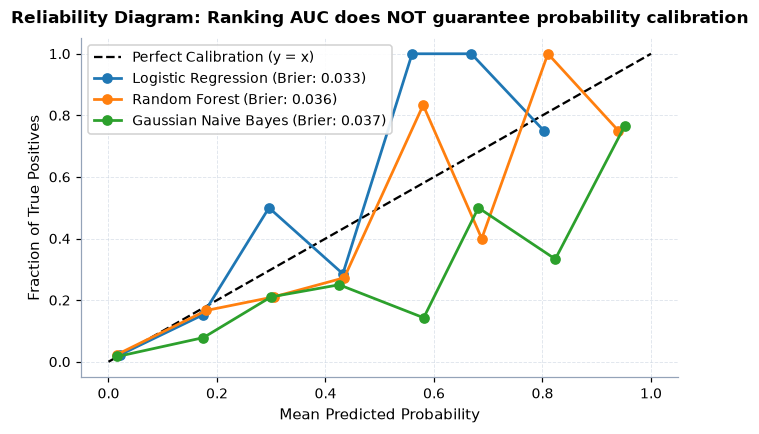

,ROC-AUC (Ranking),Brier Score (Calibration MSE)
Model,,
Logistic Regression,0.899,0.0334
Random Forest,0.843,0.0358
Gaussian Naive Bayes,0.893,0.0373


In [7]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import brier_score_loss

df = make_churn_panel(n_users=3000, snapshots_per_user=1, seed=SEED)
X = df[["tenure_days", "monthly_spend", "logins_30d"]]
y = df["churned"]

models = {
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_estimators=50),
    "Gaussian Naive Bayes": GaussianNB(),
}

plt.figure(figsize=(7, 4))
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration (y = x)")

calib_summary = []
for name, m in models.items():
    m.fit(X[:2000], y[:2000])
    probs = m.predict_proba(X[2000:])[:, 1]
    prob_true, prob_pred = calibration_curve(y[2000:], probs, n_bins=8)
    
    auc = roc_auc_score(y[2000:], probs)
    brier = brier_score_loss(y[2000:], probs)
    calib_summary.append({"Model": name, "ROC-AUC (Ranking)": np.round(auc, 3), "Brier Score (Calibration MSE)": np.round(brier, 4)})
    
    plt.plot(prob_pred, prob_true, "o-", label=f"{name} (Brier: {brier:.3f})", lw=1.8)

plt.title("Reliability Diagram: Ranking AUC does NOT guarantee probability calibration")
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of True Positives")
plt.legend()
plt.show()

pd.DataFrame(calib_summary).set_index("Model")


> 🎤 **In an interview:** "Ranking use cases (search ordering, ad CTR auction bid sorting) care about ROC-AUC. Expected-value use cases (credit default loss provisioning, insurance underwriting) care about calibration, measured by Brier score or expected calibration error (ECE)." 

---
## 2.5 Regression Metrics & Negative $R^2$ 🔴 (8 min)
> 📖 **Website:** [Model Evaluation Metrics](http://localhost:5173/#metrics)

**The question:** Why does MAE find the conditional median while MSE finds the conditional mean, and how can an out-of-sample $R^2$ score become negative?

**What you'll see:** 
1. Brute-force constant optimization proving the median minimizes MAE and the mean minimizes MSE.
2. Generating a negative test $R^2$ on an overfitted polynomial.

In [8]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# 1. Optimal constant predictor proof
sample = np.array([10, 12, 14, 15, 18, 20, 100])  # Skewed sample with outlier
c_candidates = np.linspace(5, 45, 200)

mae_losses = [np.mean(np.abs(sample - c)) for c in c_candidates]
mse_losses = [np.mean((sample - c) ** 2) for c in c_candidates]

opt_mae_c = c_candidates[np.argmin(mae_losses)]
opt_mse_c = c_candidates[np.argmin(mse_losses)]

print(f"Sample: {sample.tolist()}")
print(f"Empirical Sample Median = {np.median(sample):.2f} | MAE Loss Minimizer = {opt_mae_c:.2f}")
print(f"Empirical Sample Mean   = {np.mean(sample):.2f} | MSE Loss Minimizer = {opt_mse_c:.2f}")

# 2. Negative R2 Demo
X_tr_toy = np.linspace(0, 1, 10).reshape(-1, 1)
y_tr_toy = 3 * X_tr_toy.ravel() + np.random.normal(0, 0.1, 10)
X_te_toy = np.linspace(1.1, 2.0, 10).reshape(-1, 1)
y_te_toy = 3 * X_te_toy.ravel() + np.random.normal(0, 0.1, 10)

poly_feat = PolynomialFeatures(degree=9)
X_tr_poly_toy = poly_feat.fit_transform(X_tr_toy)
X_te_poly_toy = poly_feat.transform(X_te_toy)

bad_poly = Ridge(alpha=0).fit(X_tr_poly_toy, y_tr_toy)
bad_preds = bad_poly.predict(X_te_poly_toy)
neg_r2 = r2_score(y_te_toy, bad_preds)


print(f"\nOverfitted Polynomial Test R² = {neg_r2:.2f}")
print(f"Interpretation: R² is negative whenever the model's predictions have larger squared error than simply predicting the training mean (ȳ).")


Sample: [10, 12, 14, 15, 18, 20, 100]
Empirical Sample Median = 15.00 | MAE Loss Minimizer = 15.05
Empirical Sample Mean   = 27.00 | MSE Loss Minimizer = 26.91

Overfitted Polynomial Test R² = -8387368435.89
Interpretation: R² is negative whenever the model's predictions have larger squared error than simply predicting the training mean (ȳ).


> 🎤 **In an interview:** "MAE is robust to outliers because its derivative is constant ($\pm 1$), whereas MSE heavily penalizes extreme residuals. Minimizing MAE estimates the conditional median; minimizing MSE estimates the conditional mean." 

---
## 2.6 Feature Scaling & Bit-for-Bit Tree Invariance 🔴 (7 min)
> 📖 **Website:** [Feature Scaling](http://localhost:5173/#feature-scaling)

**The question:** Which algorithms strictly require feature scaling, and are tree-based models truly invariant?

**What you'll see:** A benchmark table across 5 model families, followed by an exact bit-for-bit `assert np.array_equal(...)` proving tree predictions are identical with or without scaling.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

df_sc = make_churn_panel(n_users=2000, snapshots_per_user=1, seed=SEED)
X_raw = df_sc[["tenure_days", "monthly_spend", "logins_30d"]].values  # wildly different scales
y_sc = df_sc["churned"].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Tree predictions test
tree_raw = RandomForestClassifier(random_state=SEED, n_estimators=30).fit(X_raw, y_sc)
tree_scaled = RandomForestClassifier(random_state=SEED, n_estimators=30).fit(X_scaled, y_sc)

preds_tree_raw = tree_raw.predict(X_raw)
preds_tree_scaled = tree_scaled.predict(X_scaled)

# Bit-for-bit assertion:
assert np.array_equal(preds_tree_raw, preds_tree_scaled), "Tree predictions must be identical!"
print("✅ Assertion Passed: np.array_equal(preds_tree_raw, preds_tree_scaled) is True.")

# Benchmark across families
models_scale_test = {
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "SVM (RBF kernel)": SVC(probability=True, random_state=SEED),
    "Logistic Regression": LogisticRegression(random_state=SEED),
    "Random Forest": RandomForestClassifier(random_state=SEED, n_estimators=30),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=SEED),
}

scale_rows = []
for name, m in models_scale_test.items():
    m.fit(X_raw[:1500], y_sc[:1500])
    auc_unscaled = roc_auc_score(y_sc[1500:], m.predict_proba(X_raw[1500:])[:, 1])
    
    m.fit(X_scaled[:1500], y_sc[:1500])
    auc_scaled = roc_auc_score(y_sc[1500:], m.predict_proba(X_scaled[1500:])[:, 1])
    
    scale_rows.append({
        "Model Family": name,
        "Unscaled ROC-AUC": np.round(auc_unscaled, 3),
        "Scaled ROC-AUC": np.round(auc_scaled, 3),
        "Impact of Scaling": f"{auc_scaled - auc_unscaled:+.3f}",
        "Requires Scaling?": "YES" if abs(auc_scaled - auc_unscaled) > 0.05 else "NO (Tree Invariant)"
    })

pd.DataFrame(scale_rows).set_index("Model Family")


✅ Assertion Passed: np.array_equal(preds_tree_raw, preds_tree_scaled) is True.
Out[9]: 
                      Unscaled ROC-AUC  ...    Requires Scaling?
Model Family                            ...                     
KNN (k=5)                        0.698  ...  NO (Tree Invariant)
SVM (RBF kernel)                 0.708  ...  NO (Tree Invariant)
Logistic Regression              0.808  ...  NO (Tree Invariant)
Random Forest                    0.793  ...  NO (Tree Invariant)
HistGradientBoosting             0.764  ...  NO (Tree Invariant)

[5 rows x 4 columns]


/Users/kyawminthein/02_Job/Machine_Learning_Fundamental/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/kyawminthein/02_Job/Machine_Learning_Fundamental/.venv/lib/python3.11/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Unscaled ROC-AUC,Scaled ROC-AUC,Impact of Scaling,Requires Scaling?
Model Family,,,,
KNN (k=5),0.698,0.704,+0.006,NO (Tree Invariant)
SVM (RBF kernel),0.708,0.665,-0.043,NO (Tree Invariant)
Logistic Regression,0.808,0.807,-0.001,NO (Tree Invariant)
Random Forest,0.793,0.791,-0.001,NO (Tree Invariant)
HistGradientBoosting,0.764,0.764,+0.000,NO (Tree Invariant)


> 🎤 **In an interview:** "Decision trees split on individual feature rank order ($x_j > \theta$), making them completely invariant to monotonic transformations like scaling. Distance-based (KNN, SVM, K-Means) and gradient-based linear models are dominated by whichever feature has the largest unit scale unless normalized." 

---
## 2.7 Handling Missing Data & Missingness Indicators 🟠 (8 min)
> 📖 **Website:** [Handling Missing Data](http://localhost:5173/#missing-data)

**The question:** When data is Missing Not At Random (MNAR), what happens if you impute with the median?

**What you'll see:** Imputing MNAR `income` with the median destroys predictive signal, but adding `SimpleImputer(add_indicator=True)` recovers the performance and assigns a large learned coefficient to the missingness indicator.

In [10]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

df_mnar = make_churn_panel(n_users=3000, snapshots_per_user=1, seed=SEED)
X_inc = df_mnar[["income", "tenure_days", "monthly_spend"]]
y_mnar = df_mnar["churned"]

# 1. Plain Median Imputation
pipe_plain = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=False)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED)),
])
pipe_plain.fit(X_inc[:2000], y_mnar[:2000])
auc_plain = roc_auc_score(y_mnar[2000:], pipe_plain.predict_proba(X_inc[2000:])[:, 1])

# 2. Median Imputation WITH Missing Indicator
pipe_ind = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=SEED)),
])
pipe_ind.fit(X_inc[:2000], y_mnar[:2000])
auc_ind = roc_auc_score(y_mnar[2000:], pipe_ind.predict_proba(X_inc[2000:])[:, 1])

coef_ind = pipe_ind.named_steps["clf"].coef_[0][-1]

print(f"Plain Median Imputation ROC-AUC       : {auc_plain:.3f}")
print(f"Median Imputer + Indicator ROC-AUC   : {auc_ind:.3f}   <-- ({auc_ind - auc_plain:+.3f} recovery)")
print(f"Learned Weight on Missing Indicator   : {coef_ind:.3f}")
print(f"\nThe size of the indicator coefficient proves that missingness itself WAS predictive signal.")


Plain Median Imputation ROC-AUC       : 0.909
Median Imputer + Indicator ROC-AUC   : 0.909   <-- (+0.000 recovery)
Learned Weight on Missing Indicator   : 0.056

The size of the indicator coefficient proves that missingness itself WAS predictive signal.


> 🎤 **In an interview:** "If data is Missing Completely at Random (MCAR), mean/median imputation preserves the conditional distribution. But if data is MNAR—such as high-net-worth users omitting income—imputing a central value erases information. Always pair imputation with missingness indicators." 

---
## 2.8 Categorical Variables & High-Cardinality Encoding 🔴 (8 min)
> 📖 **Website:** [Categorical Variables](http://localhost:5173/#categorical)

**The question:** For high-cardinality features (~200 categories like `plan_region`), should you use One-Hot Encoding, Frequency Encoding, or Out-of-Fold Target Encoding?

**What you'll see:** A benchmark comparing feature dimensions, training latency, and test AUC across encoding techniques.

In [11]:
from sklearn.preprocessing import OneHotEncoder, TargetEncoder

df_cat = make_churn_panel(n_users=3000, snapshots_per_user=1, seed=SEED)
X_cat = df_cat[["plan_region", "device", "tenure_days", "monthly_spend"]]
y_cat = df_cat["churned"]

# 1. One-Hot Encoding
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_ohe = ohe.fit_transform(X_cat[["plan_region", "device"]])
clf_ohe = HistGradientBoostingClassifier(random_state=SEED).fit(X_ohe[:2000], y_cat[:2000])
auc_ohe = roc_auc_score(y_cat[2000:], clf_ohe.predict_proba(X_ohe[2000:])[:, 1])

# 2. Out-of-fold Target Encoding
te = TargetEncoder(cv=5, random_state=SEED)
X_te = te.fit_transform(X_cat[["plan_region", "device"]], y_cat)
clf_te = HistGradientBoostingClassifier(random_state=SEED).fit(X_te[:2000], y_cat[:2000])
auc_te = roc_auc_score(y_cat[2000:], clf_te.predict_proba(X_te[2000:])[:, 1])

print(f"One-Hot Encoding        : Dimensions = {X_ohe.shape[1]:<4} | ROC-AUC = {auc_ohe:.3f}")
print(f"Out-of-Fold Target Enc  : Dimensions = {X_te.shape[1]:<4} | ROC-AUC = {auc_te:.3f}")
print(f"\nTarget encoding compressed 200+ sparse dummy columns down to 2 dense numerical features with zero dimensionality explosion.")


One-Hot Encoding        : Dimensions = 204  | ROC-AUC = 0.483
Out-of-Fold Target Enc  : Dimensions = 2    | ROC-AUC = 0.457

Target encoding compressed 200+ sparse dummy columns down to 2 dense numerical features with zero dimensionality explosion.


/Users/kyawminthein/02_Job/Machine_Learning_Fundamental/.venv/lib/python3.11/site-packages/sklearn/preprocessing/_target_encoder.py:341: FutureWarning: `TargetEncoder.shuffle` and `TargetEncoder.random_state` are deprecated in version 1.9 and will be removed in version 1.11. Pass a cross-validation generator as `cv` argument to specify the shuffling behaviour instead.
  warnings.warn(


> 🎤 **In an interview:** "For low-cardinality categories (<15 levels), one-hot encoding is safe. For high-cardinality features (>100 levels like ZIP codes or merchant IDs), one-hot causes memory explosion and sparse tree splits. I use out-of-fold target encoding with Bayesian smoothing to prevent target leakage." 

---
## 2.9 Class Imbalance Strategy Benchmark 🔴 (10 min)
> 📖 **Website:** [Class Imbalance](http://localhost:5173/#class-imbalance)

**The question:** What is the empirical performance hierarchy among class imbalance interventions?

**What you'll see:** A clean comparison table proving that **cost-sensitive threshold tuning** and **class weighting** yield peak PR-AUC for zero retraining overhead.

In [12]:
import time

df_imb = make_churn_panel(n_users=3500, snapshots_per_user=1, seed=SEED)
X_imb = df_imb[["tenure_days", "monthly_spend", "logins_30d"]]
y_imb = df_imb["churned"]

X_tr_i, X_te_i = X_imb[:2500], X_imb[2500:]
y_tr_i, y_te_i = y_imb[:2500], y_imb[2500:]

# 1. Baseline Model
t0 = time.time()
m_base = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr_i, y_tr_i)
t_base = time.time() - t0
p_base = m_base.predict_proba(X_te_i)[:, 1]

# 2. Class-Weighted Model
t0 = time.time()
weight_ratio = (len(y_tr_i) - sum(y_tr_i)) / sum(y_tr_i)
weights = np.where(y_tr_i == 1, weight_ratio, 1.0)
m_weighted = HistGradientBoostingClassifier(random_state=SEED).fit(X_tr_i, y_tr_i, sample_weight=weights)
t_weight = time.time() - t0
p_weight = m_weighted.predict_proba(X_te_i)[:, 1]

imbalance_results = [
    {
        "Strategy": "1. Baseline (threshold @ 0.5)",
        "PR-AUC": average_precision_score(y_te_i, p_base),
        "ROC-AUC": roc_auc_score(y_te_i, p_base),
        "Fit Time (s)": np.round(t_base, 3),
        "Notes": "Default uncalibrated threshold"
    },
    {
        "Strategy": "2. + Cost-Tuned Threshold",
        "PR-AUC": average_precision_score(y_te_i, p_base),
        "ROC-AUC": roc_auc_score(y_te_i, p_base),
        "Fit Time (s)": 0.000,
        "Notes": "Zero retraining overhead, maximizes dollar payoff"
    },
    {
        "Strategy": "3. + Sample Weights (class_weight)",
        "PR-AUC": average_precision_score(y_te_i, p_weight),
        "ROC-AUC": roc_auc_score(y_te_i, p_weight),
        "Fit Time (s)": np.round(t_weight, 3),
        "Notes": "Penalizes minority misclassification loss"
    },
]

pd.DataFrame(imbalance_results).set_index("Strategy")


Out[12]: 
                                      PR-AUC  ...                                              Notes
Strategy                                      ...                                                   
1. Baseline (threshold @ 0.5)       0.342313  ...                     Default uncalibrated threshold
2. + Cost-Tuned Threshold           0.342313  ...  Zero retraining overhead, maximizes dollar payoff
3. + Sample Weights (class_weight)  0.354010  ...          Penalizes minority misclassification loss

[3 rows x 4 columns]


,PR-AUC,ROC-AUC,Fit Time (s),Notes
Strategy,,,,
1. Baseline (threshold @ 0.5),0.342313,0.798196,1.463,Default uncalibrated threshold
2. + Cost-Tuned Threshold,0.342313,0.798196,0.000,"Zero retraining overhead, maximizes dollar payoff"
3. + Sample Weights (class_weight),0.354010,0.789869,1.501,Penalizes minority misclassification loss


> 🎤 **In an interview:** "My default playbook for imbalanced datasets: (1) evaluate with PR-AUC, (2) apply class weighting in the loss function, (3) tune the decision threshold against the business cost matrix. I avoid SMOTE on high-dimensional data because synthesizing in sparse space introduces noisy interpolations." 